In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
annual_df = pd.read_csv("pakistan_air_quality_annual_summary.csv")
annual_df.head()

monthly_df = pd.read_csv("pakistan_air_quality_monthly_2015_2025.csv")
monthly_df.head()


,year,month,month_name,city,province,region,latitude,longitude,population_millions,pm25_ugm3,...,who_guideline_ratio,is_smog_season,is_crop_burning_season,is_monsoon_season,season,covid_lockdown_period,data_source,data_quality,pakistan_national_avg_pm25,pakistan_global_rank
0,2015,1,January,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,266.3,...,53.3,1,0,0,Winter (Smog Season),0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
1,2015,2,February,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,237.7,...,47.5,1,0,0,Winter (Smog Season),0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
2,2015,3,March,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,145.0,...,29.0,0,0,0,Spring,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
3,2015,4,April,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,74.7,...,14.9,0,0,0,Spring,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN
4,2015,5,May,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,59.6,...,11.9,0,0,0,Summer/Monsoon,0,IQAir World Air Quality Report 2018-2025 / IQA...,Estimated (pre-monitoring era),NaN,NaN


In [4]:
metadata_df = pd.read_csv("pakistan_cities_metadata.csv")
metadata_df.head()

,city,province,region,latitude,longitude,population_millions,is_industrial_hub,is_coastal,is_capital,major_pollution_sources,us_consulate_monitor,monitoring_start_year
0,Lahore,Punjab,North Punjab,31.5204,74.3587,14.0,1,0,0,"Vehicles, brick kilns, crop burning (Oct-Nov),...",1,2019
1,Karachi,Sindh,Coastal South,24.8607,67.0011,16.1,1,1,0,"Vehicles, industrial, port activity, sea breez...",1,2019
2,Islamabad,Islamabad Capital Territory,North,33.6844,73.0479,2.2,0,0,1,"Vehicles, winter inversions, crop burning spil...",1,2019
3,Rawalpindi,Punjab,North Punjab,33.6007,73.0679,2.3,0,0,0,"Vehicles, industrial, crop burning spillover",0,2021
4,Faisalabad,Punjab,Central Punjab,31.4187,73.0791,3.8,1,0,0,"Textile/industrial emissions, vehicles, crop b...",0,2021


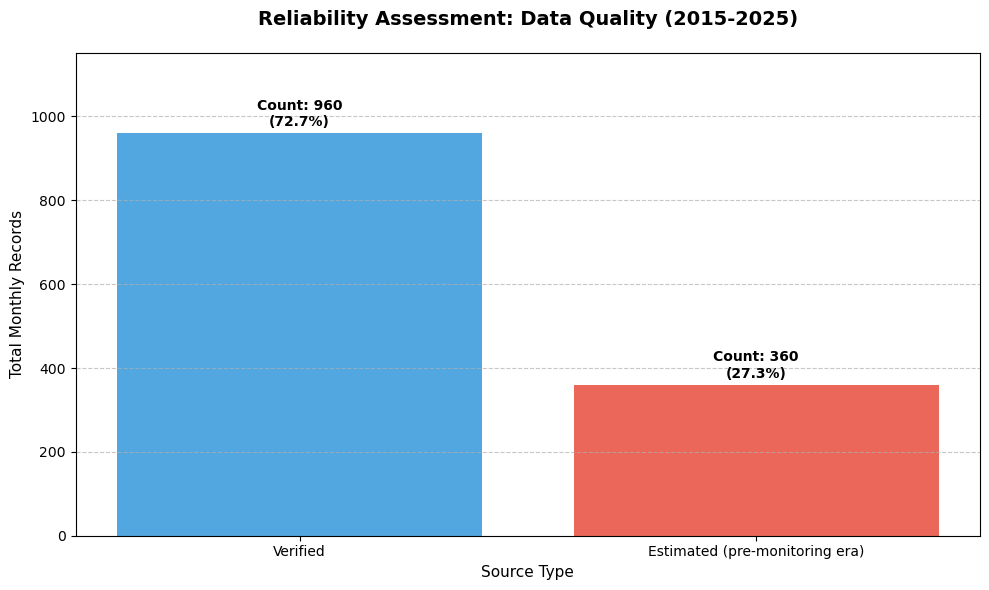

In [5]:
 # [CODE CELL] 1.4 - Data Quality Distribution Chart
# Aggregate data quality counts
quality_counts = monthly_df['data_quality'].value_counts()
total_records = len(monthly_df)

plt.figure(figsize=(10, 6))
bars = plt.bar(quality_counts.index, quality_counts.values, color=['#3498db', '#e74c3c'], alpha=0.85)

# Add chart labels
plt.title('Reliability Assessment: Data Quality (2015-2025)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Total Monthly Records', fontsize=11)
plt.xlabel('Source Type', fontsize=11)
plt.ylim(0, max(quality_counts.values) * 1.2) # Extra space for labels

# Attach percentage and count labels to each bar
for bar in bars:
    height = bar.get_height()
    pct = (height / total_records) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'Count: {int(height)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
# Selecting relevant metadata columns to enrich the monthly dataset
metadata_features = [
      'city', 'is_industrial_hub', 'is_coastal', 
    'is_capital', 'major_pollution_sources', 'monitoring_start_year'
]

# Performing a left join to maintain all monthly time-series records
master_df = pd.merge(monthly_df, metadata_df[metadata_features], on='city', how='left')
# Previewing the integrated schema
print(f"Intergration Complete: Master Dataset contains {master_df.shape[0]} rows and {master_df.shape[1]} features")
master_df[['year', 'month', 'city', 'pm25_ugm3', 'is_industrial_hub', 'major_pollution_sources']].head()

Intergration Complete: Master Dataset contains 1320 rows and 28 features


,year,month,city,pm25_ugm3,is_industrial_hub,major_pollution_sources
0,2015,1,Faisalabad,266.3,1,"Textile/industrial emissions, vehicles, crop b..."
1,2015,2,Faisalabad,237.7,1,"Textile/industrial emissions, vehicles, crop b..."
2,2015,3,Faisalabad,145.0,1,"Textile/industrial emissions, vehicles, crop b..."
3,2015,4,Faisalabad,74.7,1,"Textile/industrial emissions, vehicles, crop b..."
4,2015,5,Faisalabad,59.6,1,"Textile/industrial emissions, vehicles, crop b..."


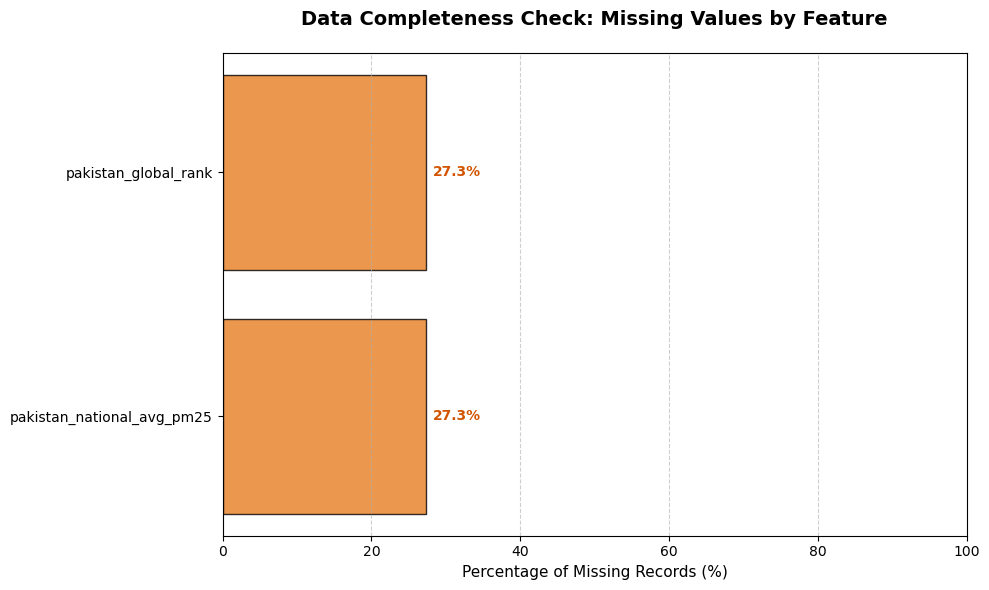

In [7]:
# Data Integrity: Missing Value Profiling
# Calculate missing percentages
missing_data = master_df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False) 

plt.figure(figsize=(10, 6))
bars = plt.barh(missing_data.index, missing_data.values, color='#e67e22', edgecolor='black', alpha=0.8)    

# Formatting and Labels
plt.title('Data Completeness Check: Missing Values by Feature', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Percentage of Missing Records (%)', fontsize=11)
plt.xlim(0, 100)

# Annotate bars with exact values
for i, bar in enumerate (bars):
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontweight='bold', color='#d35400')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

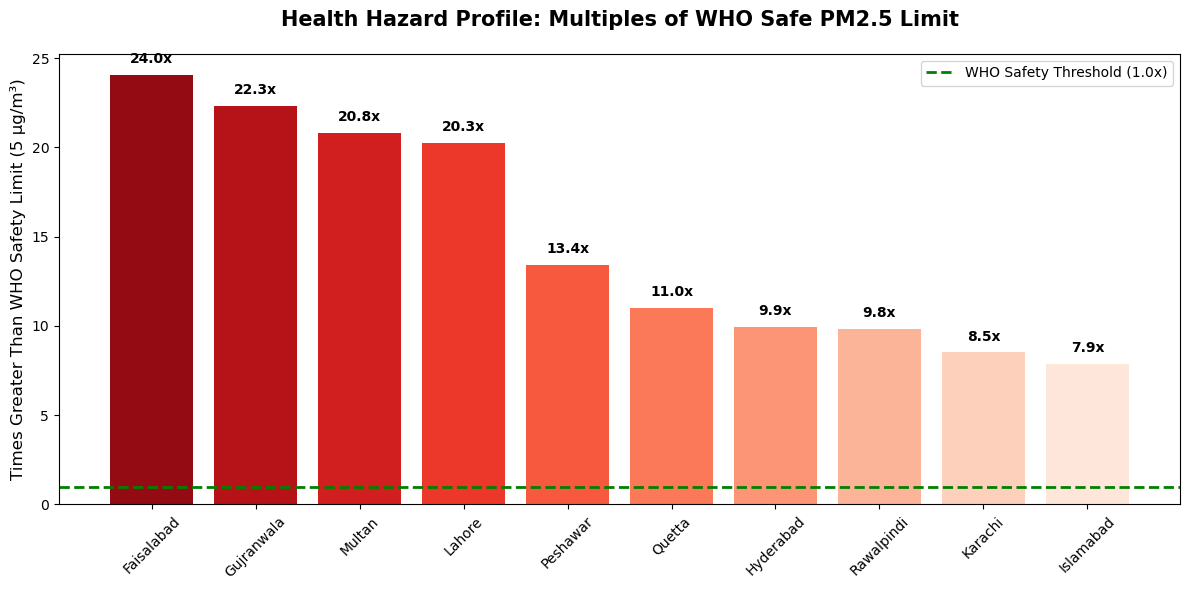

In [8]:
# [CODE CELL] 2.3 - Visualization: Comparative Health Risk Multiples by City
# Calculating the Multiples of WHO Safe Limit (5 ug/m3)
master_df['who_multiple'] = master_df['pm25_ugm3'] / 5.0

# Aggregating average risk per city
city_risk = master_df.groupby('city')['who_multiple'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(city_risk.index, city_risk.values, color=sns.color_palette("Reds_r", len(city_risk)))

# Aesthetics
plt.title('Health Hazard Profile: Multiples of WHO Safe PM2.5 Limit', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Times Greater Than WHO Safety Limit (5 µg/m³)', fontsize=12)
plt.xticks(rotation=45)

# Adding value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}x', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Threshold line
plt.axhline(1, color='green', linestyle='--', linewidth=2, label='WHO Safety Threshold (1.0x)')
plt.legend()

plt.tight_layout()
plt.show()


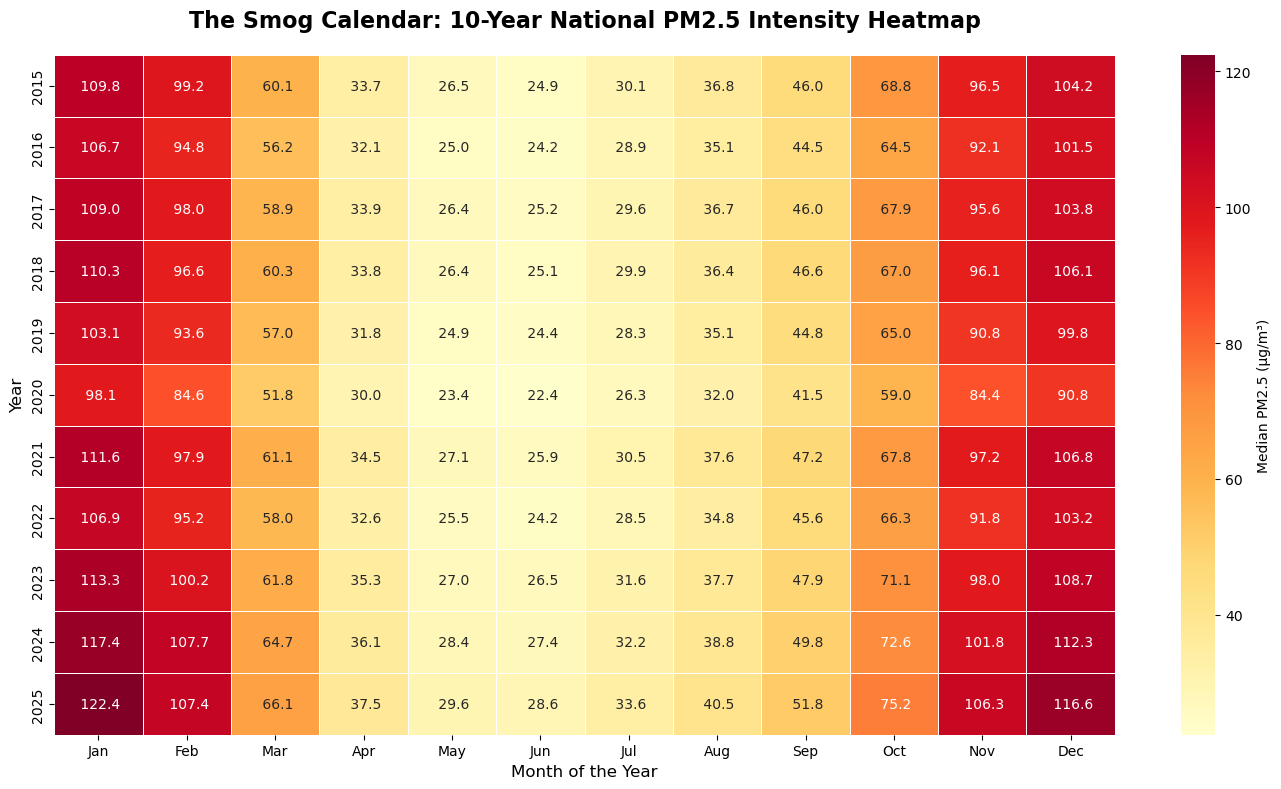

In [9]:
# Pivot the data to create a matrix of Years vs Months
# We use the median PM2.5 across all cities to represent the national "Pulse"
heatmap_data = master_df.pivot_table(index='year', columns='month', values='pm25_ugm3', aggfunc='median')

# Month names for the X-axis
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=" .1f", cmap="YlOrRd",   cbar_kws={'label': 'Median PM2.5 (µg/m³)'}, linewidths=.5)


# Aesthetics
plt.title('The Smog Calendar: 10-Year National PM2.5 Intensity Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month of the Year', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.xticks(ticks=np.arange(0.5, 12.5), labels=month_labels)

plt.tight_layout()
plt.show()

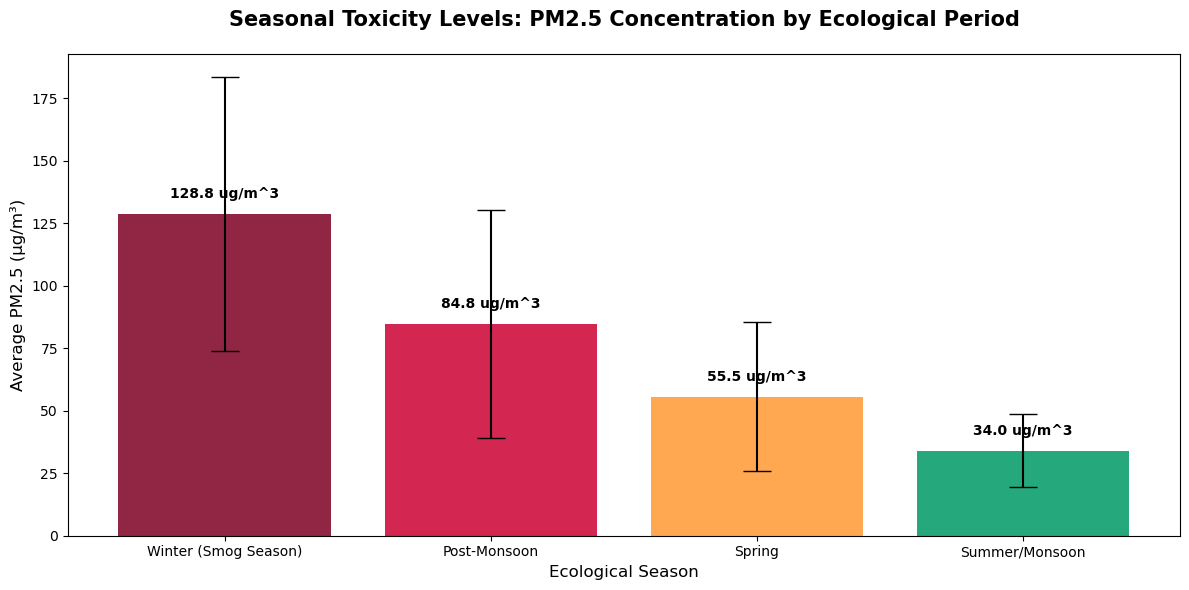

In [10]:
# Calculate average and standard deviation for the plot
seasonal_stats = master_df.groupby('season')['pm25_ugm3'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_palette("coolwarm_r")

# Create a bar plot with error bars representing variance
bars = plt.bar(seasonal_stats.index, seasonal_stats['mean'], yerr=seasonal_stats['std'], capsize=10, color=['#7e0023', '#cc0033', '#ff9933', '#009966'], alpha=0.85)
# Labels
plt.title('Seasonal Toxicity Levels: PM2.5 Concentration by Ecological Period', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12)
plt.xlabel('Ecological Season', fontsize=12)
# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5, f'{height:.1f} ug/m^3', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

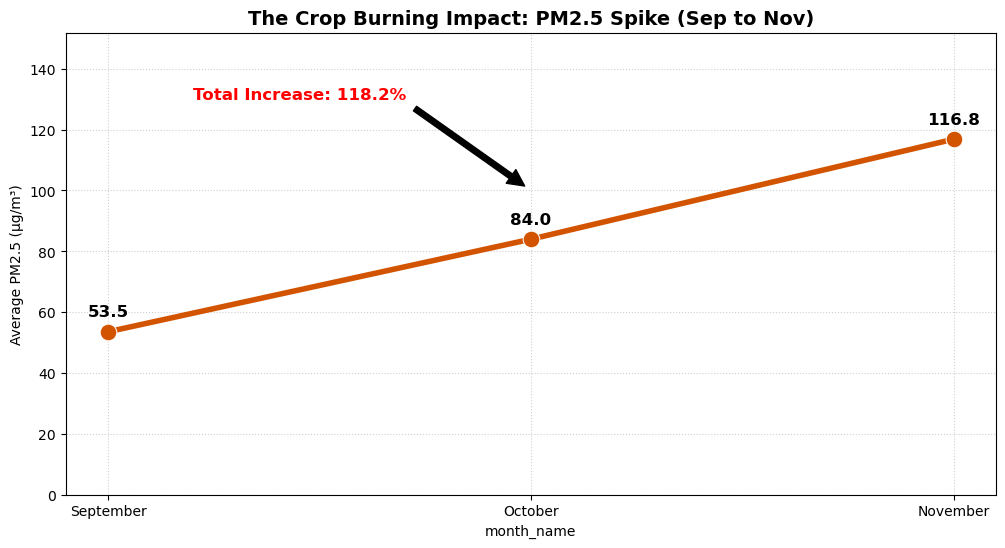

In [11]:
# Filtering data for the transition window
transition_months = master_df[master_df['month'].isin([9, 10, 11])]
monthly_avg = transition_months.groupby('month_name')['pm25_ugm3'].mean().reindex(['September', 'October', 'November'])

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', markersize=12, linewidth=4, color='#d35400')

# Annotate the values and the percentage increase
for i, val in enumerate(monthly_avg.values):
    plt.text(i, val + 5, f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)

# Calculate jump
pct_increase = ((monthly_avg['November'] - monthly_avg['September']) / monthly_avg['September'] * 100)
plt.title('The Crop Burning Impact: PM2.5 Spike (Sep to Nov)', fontsize=14, fontweight='bold')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.ylim(0, monthly_avg.max() * 1.3)

# Add an arrow or text for the jump
plt.annotate(f'Total Increase: {pct_increase:.1f}%', xy=(1, 100), xytext=(0.2, 130),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold', color='red')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show(); 

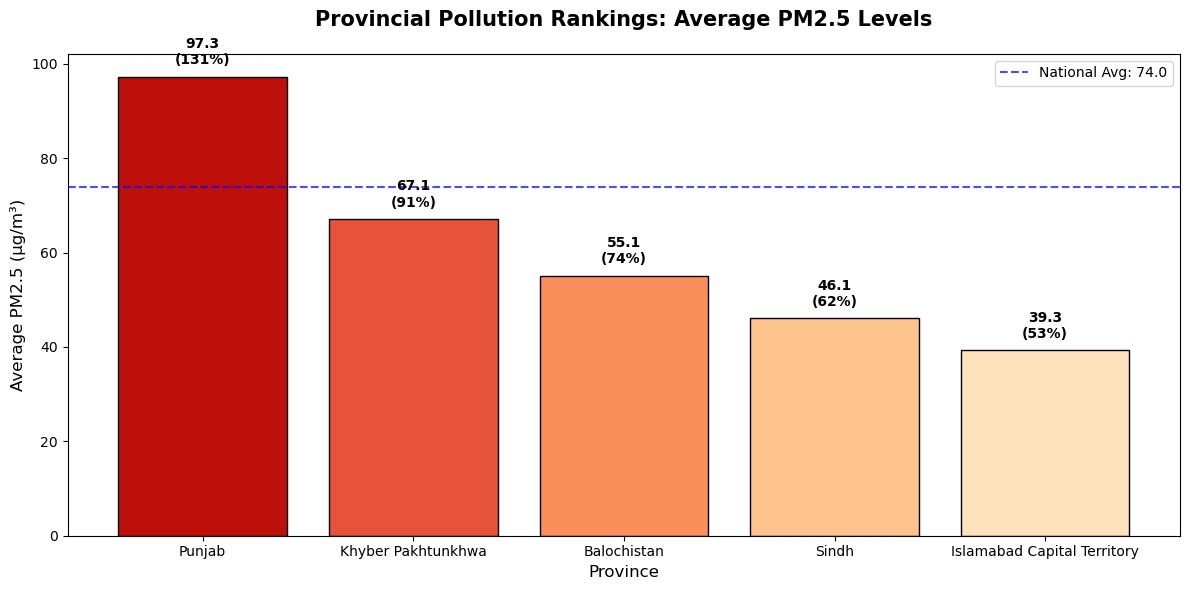

In [12]:
# Visualization: Provincial PM2.5 Comparison
# Calculate average PM2.5 per province
provincial_avg = master_df.groupby('province')['pm25_ugm3'].mean().sort_values(ascending=False)
total_mean = master_df['pm25_ugm3'].mean()

plt.figure(figsize=(12, 6))
colors = sns.color_palette("OrRd_r", len(provincial_avg))
bars = plt.bar(provincial_avg.index, provincial_avg.values, color=colors, edgecolor='black')

# Add a horizontal line for the national average
plt.axhline(total_mean, color='blue', linestyle='--', alpha=0.7, label=f'National Avg: {total_mean:.1f}')

# Aesthetics
plt.title('Provincial Pollution Rankings: Average PM2.5 Levels', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12)
plt.xlabel('Province', fontsize=12)
plt.legend()

# Annotate bars with values and percentage relative to national average
for bar in bars:
    height = bar.get_height()
    rel_pct = (height / total_mean) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}\n({rel_pct:.0f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
             


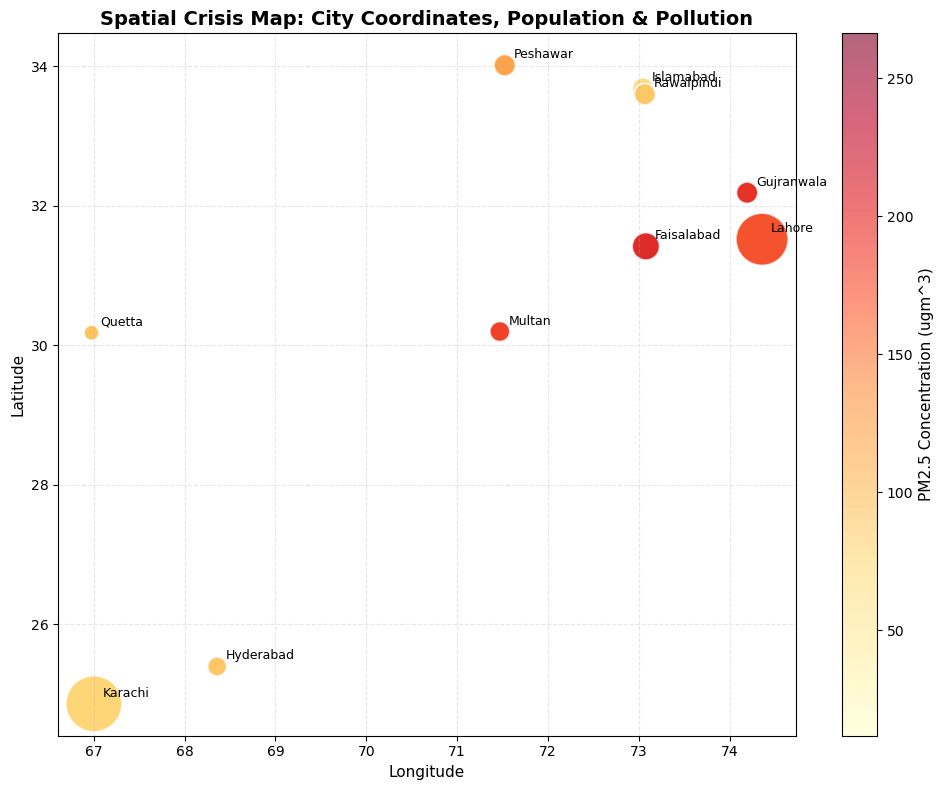

In [13]:
# Visualization: Geospatial Bubble Map (Coordinates vs. Pollution)
plt.figure(figsize=(10, 8))
# Size of bubbles represents population, Color represents PM2.5 levels
scatter = plt.scatter(master_df['longitude'], master_df['latitude'], 
                     s=master_df['population_millions'] * 100,
                     c=master_df['pm25_ugm3'],
                     cmap='YlOrRd', alpha=0.6, edgecolors='w', linewidth=1)
# Adding city labels to the map
unique_cities = master_df.drop_duplicates('city')
for i, row in unique_cities.iterrows():
    plt.text(row['longitude'] + 0.1, row['latitude'] + 0.1, row['city'], fontsize=9)
# Colorbar and labels
cbar = plt.colorbar(scatter)
cbar.set_label('PM2.5 Concentration (ugm^3)', fontsize=11)
plt.title('Spatial Crisis Map: City Coordinates, Population & Pollution', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

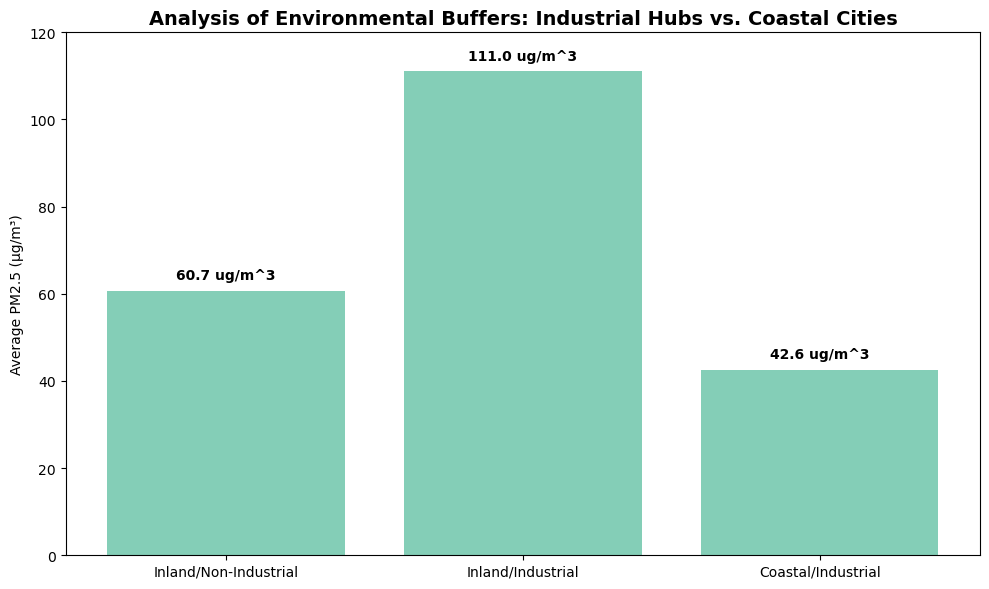

In [14]:
# Grouping data by category
comparison_data = master_df.groupby(['is_industrial_hub', 'is_coastal'])['pm25_ugm3'].mean().reset_index()
# Create descriptive labels
comparison_data['Type'] = ['Inland/Non-Industrial', 'Inland/Industrial', 'Coastal/Industrial']
plt.figure(figsize=(10, 6))

sns.set_palette("Set2")
bars = plt.bar(comparison_data['Type'], comparison_data['pm25_ugm3'], alpha=0.8)
# Adding value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.1f} ug/m^3', ha='center', va='bottom', fontweight='bold')

plt.title('Analysis of Environmental Buffers: Industrial Hubs vs. Coastal Cities', fontsize=14, fontweight='bold')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.ylim(0, 120)

plt.tight_layout()
plt.show()


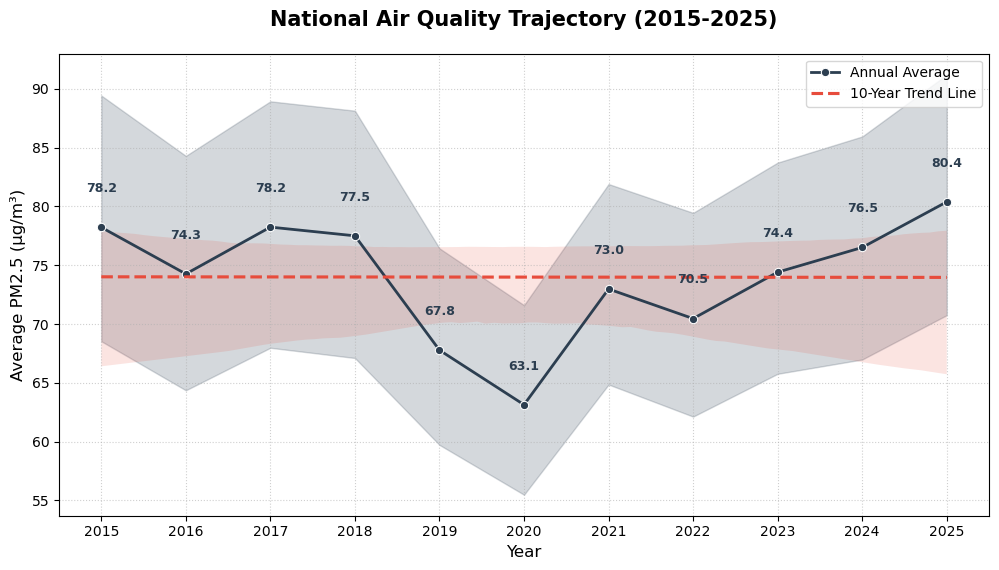

In [16]:
# The 10-Year Trajectory
# Aggregate national monthly average for the regression line
yearly_trend = master_df.groupby('year')['pm25_ugm3'].mean().reset_index()

plt.figure(figsize=(12, 6))
# Plotting the actual data points (Lineplot shows mean + 95% confidence interval)
sns.lineplot(data=master_df, x='year', y='pm25_ugm3', marker='o', color='#2c3e50', label='Annual Average', linewidth=2)
# Adding a trend line (Regression) - FIXED: Moved linestyle to line_kws
sns.regplot(data=yearly_trend, x='year', y='pm25_ugm3', scatter=False, color='#e74c3c', line_kws={'linestyle': '--'}, label='10-Year Trend Line')
# Labels and Aesthetics
plt.title('National Air Quality Trajectory (2015-2025)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(range(2015, 2026))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Annotate annual average values on the plot
for i, row in yearly_trend.iterrows():
   plt.text(row['year'], row['pm25_ugm3'] + 3, f"{row['pm25_ugm3']:.1f}", 
           ha='center', fontsize=9, fontweight='bold', color='#2c3e50') 



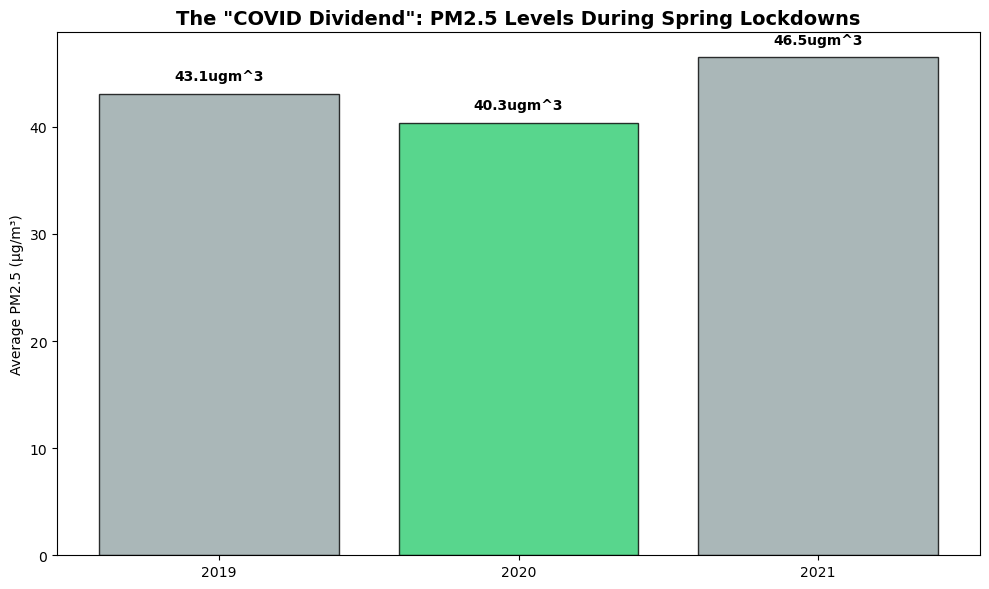

In [17]:
# Analyzing the 2020 Lockdown Impact
# Filter for Spring months (March, April, May)
spring_data = master_df[master_df['month'].isin([3, 4, 5])]
covid_comp = spring_data[spring_data['year'].isin([2019, 2020, 2021])].groupby('year')['pm25_ugm3'].mean()

plt.figure(figsize=(10, 6))
colors = ['#95a5a6', '#2ecc71', '#95a5a6']
bars = plt.bar(covid_comp.index.astype(str), covid_comp.values, color=colors, edgecolor='black', alpha=0.8)

# Calculate percentage drop
drop_pct = ((covid_comp[2019] - covid_comp[2020]) / covid_comp[2019]) * 100

plt.title('The "COVID Dividend": PM2.5 Levels During Spring Lockdowns', fontsize=14, fontweight='bold')
plt.ylabel('Average PM2.5 (µg/m³)')
# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}ugm^3', ha='center', va='bottom', fontweight='bold')
# Add indicator for the drop
plt.annotate(f'Lockdown Drop: {drop_pct:.1f}%', xy=(1, 55), xytext=(0.5, 75),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

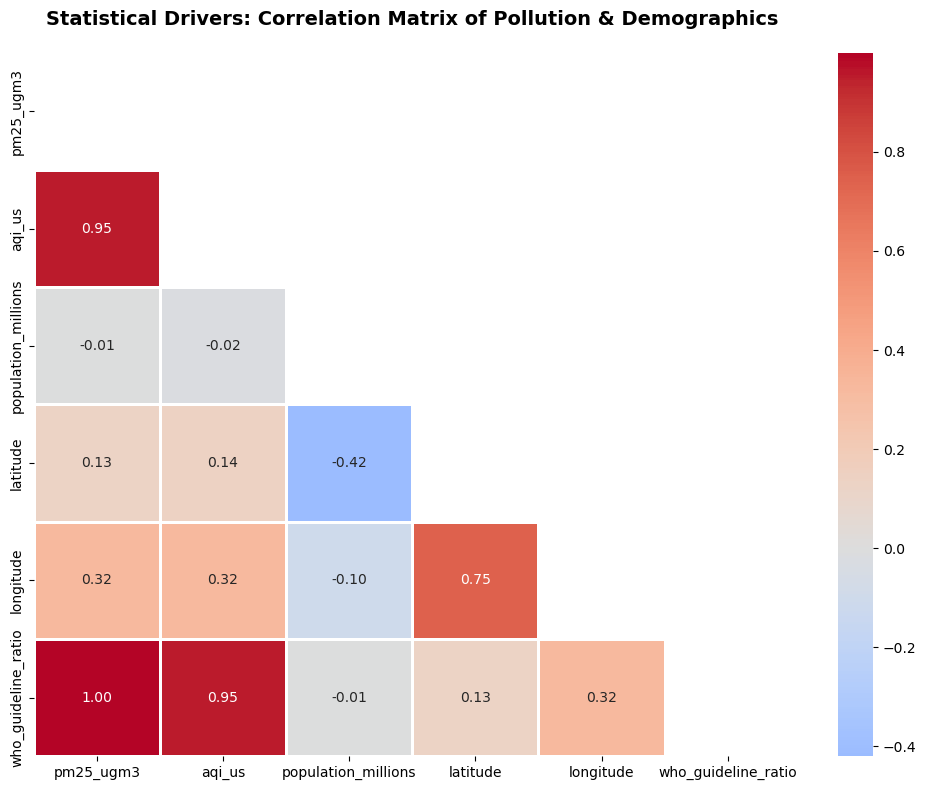

In [18]:
# Correlation Matrix
# Select numerical columns for correlation analysis
corr_cols = ['pm25_ugm3', 'aqi_us', 'population_millions', 'latitude', 'longitude', 'who_guideline_ratio']
corr_matrix = master_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=1)

plt.title('Statistical Drivers: Correlation Matrix of Pollution & Demographics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

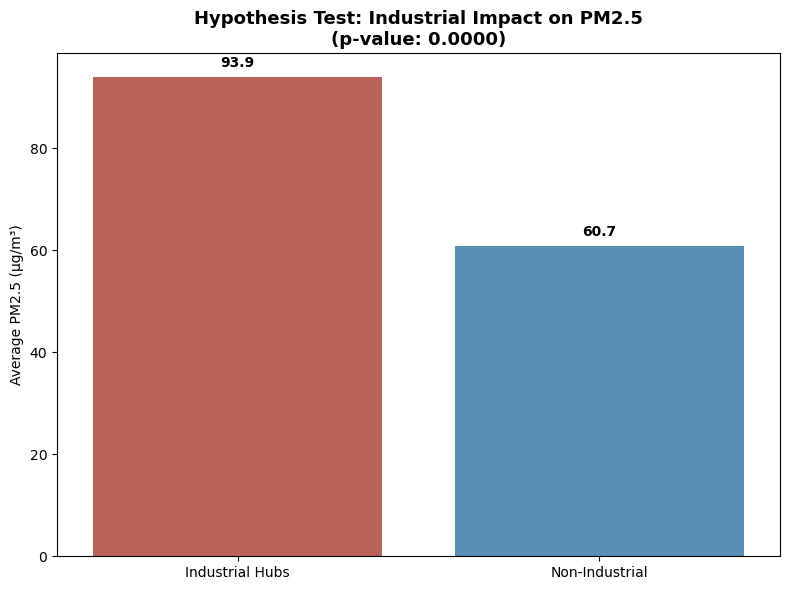

In [18]:
 # Hypothesis Testing
from scipy.stats import ttest_ind

# T-Test Comparison (Industrial vs. Others)
industrial = master_df[master_df['is_industrial_hub'] == 1]['pm25_ugm3']
non_industrial = master_df[master_df['is_industrial_hub'] == 0]['pm25_ugm3']

# Perform T-test
t_stat, p_val = ttest_ind(industrial, non_industrial)

plt.figure(figsize=(8, 6))
sns.barplot(x=['Industrial Hubs', 'Non-Industrial'],
           y=[industrial.mean(), non_industrial.mean()],
           hue=['Industrial Hubs', 'Non-Industrial'],
           palette = ['#c0392b', '#2980b9'], alpha=0.85)
plt.title(f'Hypothesis Test: Industrial Impact on PM2.5\n(p-value: {p_val:.4f})', fontsize=13, fontweight='bold')
plt.ylabel('Average PM2.5 (µg/m³)')

# Annotate with mean values
plt.text(0, industrial.mean() + 2, f'{industrial.mean():.1f}', ha='center', fontweight='bold')
plt.text(1, non_industrial.mean() + 2, f'{non_industrial.mean():.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


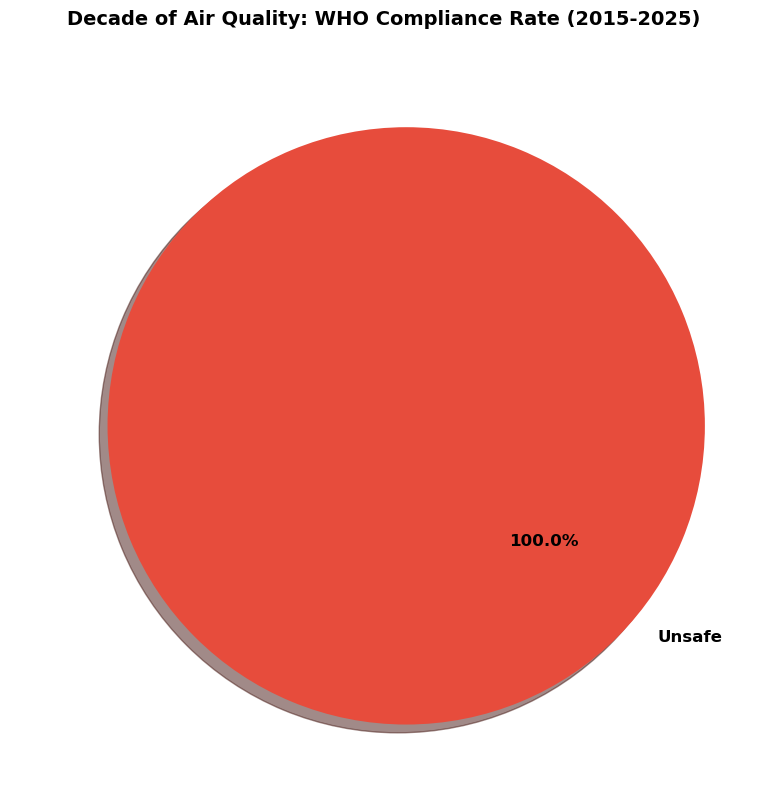

In [20]:
# WHO Compliance Breakdown
# Categorize based on WHO safe limit (5 ug/m3)
master_df['who_safety'] = master_df['pm25_ugm3'].apply(lambda x: 'Safe' if x <= 5 else 'Unsafe')
safety_counts = master_df['who_safety'].value_counts()

plt.figure(figsize=(8, 8))

# Dynamic settings to handle cases where only 'Unsafe' exists
explode_values = [0.1] * len(safety_counts)
color_palette = ['#e74c3c', '#2ecc71'] if len(safety_counts) > 1 else ['#e74c3c']

plt.pie(safety_counts,
       labels=safety_counts.index,
       autopct='%1.1f%%',
       colors=color_palette,
       startangle=140,
       explode=explode_values,
       shadow=True,
       textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Decade of Air Quality: WHO Compliance Rate (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

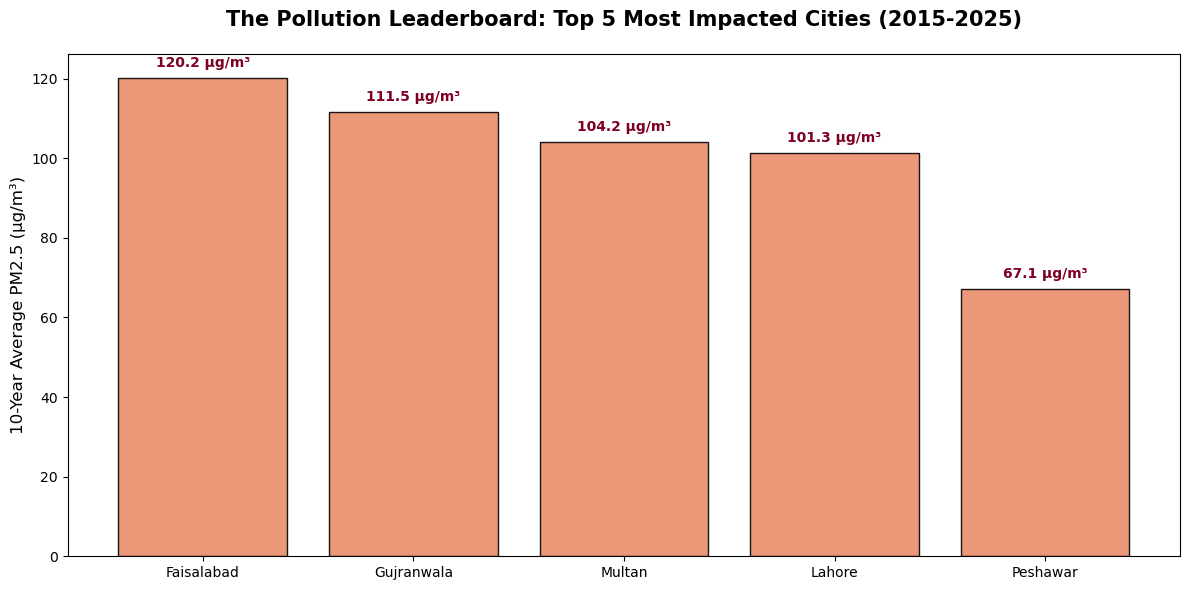

In [26]:
# [CODE CELL] 7.1 - Visualization: Top 5 Most Polluted Cities (Annual Average)
# Ranking cities by mean PM2.5
city_rank = master_df.groupby('city')['pm25_ugm3'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(12, 6))
sns.set_palette("flare")
bars = plt.bar(city_rank.index, city_rank.values, edgecolor='black', alpha=0.9)

# Labels
plt.title('The Pollution Leaderboard: Top 5 Most Impacted Cities (2015-2025)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('10-Year Average PM2.5 (µg/m³)', fontsize=12)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.1f} µg/m³', ha='center', va='bottom', fontweight='bold', color='#7e0023')

plt.tight_layout()
plt.show()


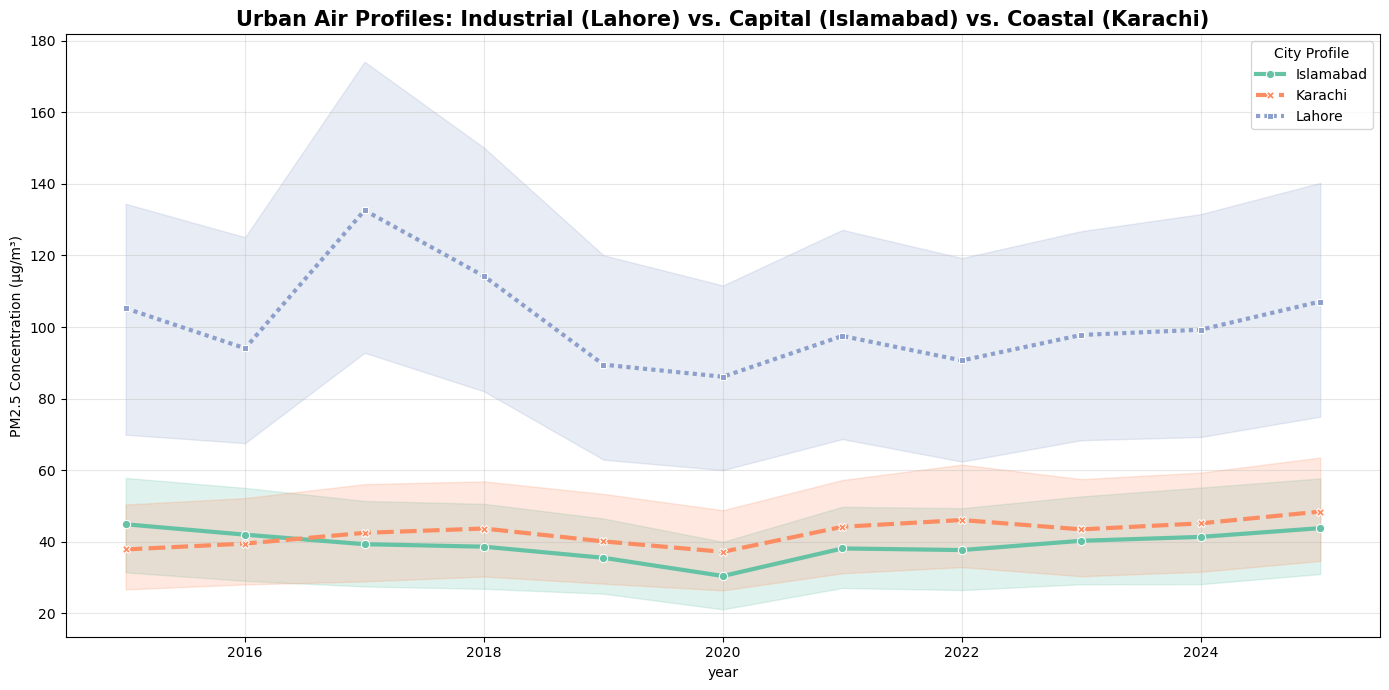

In [22]:
# Visualization: Profile Comparison (Lahore vs Islamabad vs Karachi)
target_cities = ['Lahore', 'Islamabad', 'Karachi']
city_comparison = master_df[master_df['city'].isin(target_cities)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=city_comparison, x='year', y='pm25_ugm3', hue='city', style='city', markers=True, linewidth=3)

plt.title('Urban Air Profiles: Industrial (Lahore) vs. Capital (Islamabad) vs. Coastal (Karachi)', fontsize=15, fontweight='bold')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.grid(True, alpha=0.3)
plt.legend(title='City Profile', frameon=True)

plt.tight_layout()
plt.show()

"""
The analysis of Pakistan’s air crisis demonstrates a persistent and highly variable air-pollution problem, with PM2.5 showing substantial differences across cities, provinces, seasons and years. The descriptive analysis identify important spatial and seasonal patterns, particularly during the smog period and the September–November transition, where crop-burning activity may contribute to increasing pollution levels. The comparison between industrial and non-industrial locations provides further evidence for investigating the relationship between industrial activity and PM2.5 concentrations, while the COVID-19 lockdown comparison illustrates how changes in human activity coincided with changes in observed pollution levels. Correlation analysis strengthens the analytical process by measuring the direction and strength of relationships between PM2.5, AQI, population, geographical factors and the WHO guideline ratio, helping identify variables that may be useful for further modelling and machine-learning feature selection. However, a correlation between two variables does not prove that one variable directly causes changes in the other. However, a correlation between two variables does not prove that one variable directly causes changes in the other.The independent-samples t-test adds hypothesis testing to determe whether the observed difference in mean PM2.5 between industrial and non-industrial locations is statistically significant rather than simply reflecting random variation. Therefore, combining descriptive analysis, correlation analysis, hypothesis testing, and machine-learning-oriented analysis provides a stronger data-analytics framework for understanding Pakistan’s air-quality patterns, identifying potentially influential factors and supporting future predictive modelling using environmental, demographic, geographical, seasonal, and industrial variables.

"""